In [37]:
import pandas as pd
from db_connection import conn, cursor

In [38]:
query = """
SELECT
    w.location_id,
    l.location,
    w.[date],
    w.rainfall,
    w.temperature,
    w.humidity,
    w.pressure,
    w.wind_speed,
    r.river_discharge,
    CASE 
        WHEN lb.date IS NOT NULL THEN 1
        ELSE 0
    END AS flood

FROM weather_data w
JOIN river_data r ON w.location_id = r.location_id
AND CAST(w.[date] AS DATE) = CAST(r.[date] AS DATE)

JOIN location_data l ON w.location_id = l.location_id

LEFT JOIN label_data lb 
ON w.date = lb.date
AND w.location_id = lb.location_id
"""

In [39]:
df = pd.read_sql(query,conn)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24168\785092515.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


# EDA

In [40]:
df.head()

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood
0,1,Hue,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0
1,1,Hue,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0
2,1,Hue,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0
3,1,Hue,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0
4,1,Hue,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18306 entries, 0 to 18305
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   location_id      18306 non-null  int64  
 1   location         18306 non-null  object 
 2   date             18306 non-null  object 
 3   rainfall         18306 non-null  float64
 4   temperature      18306 non-null  float64
 5   humidity         18306 non-null  float64
 6   pressure         18306 non-null  float64
 7   wind_speed       18306 non-null  float64
 8   river_discharge  18306 non-null  float64
 9   flood            18306 non-null  int64  
dtypes: float64(6), int64(2), object(2)
memory usage: 1.4+ MB


In [42]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18306 entries, 0 to 18305
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   location_id      18306 non-null  int64         
 1   location         18306 non-null  object        
 2   date             18306 non-null  datetime64[ns]
 3   rainfall         18306 non-null  float64       
 4   temperature      18306 non-null  float64       
 5   humidity         18306 non-null  float64       
 6   pressure         18306 non-null  float64       
 7   wind_speed       18306 non-null  float64       
 8   river_discharge  18306 non-null  float64       
 9   flood            18306 non-null  int64         
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 1.4+ MB


In [43]:
df = df.drop(columns = ['location'])
df.head()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood
0,1,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0
1,1,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0
2,1,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0
3,1,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0
4,1,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0


In [44]:
df.isnull().sum()

location_id        0
date               0
rainfall           0
temperature        0
humidity           0
pressure           0
wind_speed         0
river_discharge    0
flood              0
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.duplicated(subset = ['location_id','date']).sum()

np.int64(0)

In [47]:
df.describe()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood
count,18306.000000,18306,18306.000000,18306.000000,18306.000000,18306.000000,18306.000000,18306.000000,18306.000000
mean,1.500000,2014-01-10 00:00:00,7.869933,25.765317,82.986398,1009.338763,14.340560,23.565921,0.175516
min,1.000000,2001-07-01 00:00:00,0.000000,14.100000,45.000000,984.400024,4.200000,0.080000,0.000000
25%,1.000000,2007-10-06 00:00:00,0.200000,23.299999,79.000000,1005.200012,11.300000,0.660000,0.000000
50%,1.500000,2014-01-10 00:00:00,2.150000,26.000000,84.000000,1008.900024,13.600000,6.530000,0.000000
75%,2.000000,2020-04-16 00:00:00,8.400000,28.400000,88.000000,1013.299988,16.600000,14.802500,0.000000
max,2.000000,2026-07-22 00:00:00,398.799988,34.599998,97.000000,1028.400024,64.599998,1569.359985,1.000000
std,0.500014,NaN,16.864720,3.290227,7.112917,5.201800,4.612380,68.753596,0.380418


### 1. Ma trận trương quan

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24168\2214046807.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Tổng số dòng trong tập dữ liệu: 18306

XẾP HẠNG TƯƠNG QUAN CỦA TẤT CẢ CÁC BIẾN VỚI 'FLOOD'
Hạng 1: rainfall             | Hệ số: 0.543
Hạng 2: river_discharge      | Hệ số: 0.434
Hạng 3: humidity             | Hệ số: 0.302
Hạng 4: wind_speed           | Hệ số: 0.288
Hạng 5: pressure             | Hệ số: 0.162
Hạng 6: location_id          | Hệ số: 0.056
Hạng 7: temperature          | Hệ số: -0.216


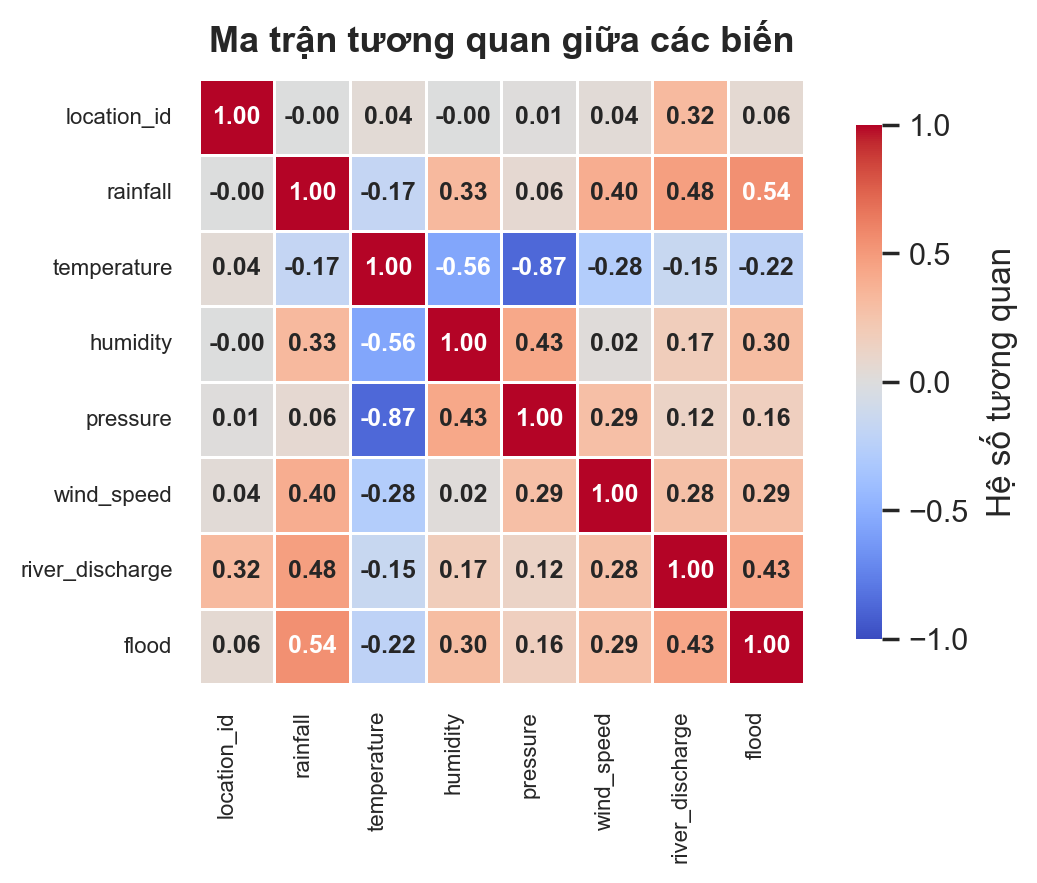

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
df = pd.read_sql(query, conn)

# 2. Chọn các biến số
du_lieu_so = df.select_dtypes(include="number")

# 3. Tính ma trận tương quan
ma_tran_tuong_quan = du_lieu_so.corr(method="pearson")

# 4. Tương quan với biến mục tiêu 'flood'
tuong_quan_voi_lu = ma_tran_tuong_quan["flood"].drop("flood")
xep_hang = tuong_quan_voi_lu.sort_values(ascending=False)

# ==============================
# IN KẾT QUẢ TỔNG QUAN
# ==============================
print(f"Tổng số dòng trong tập dữ liệu: {len(df)}")

print("\n" + "="*50)
print("XẾP HẠNG TƯƠNG QUAN CỦA TẤT CẢ CÁC BIẾN VỚI 'FLOOD'")
print("="*50)

# Sử dụng enumerate để đánh số thứ tự từ 1
for i, (bien, gia_tri) in enumerate(xep_hang.items(), 1):
    print(f"Hạng {i}: {bien:<20} | Hệ số: {gia_tri:.3f}")

print("="*50)

# ==============================
# ==============================
# Vẽ biểu đồ
# ==============================
sns.set_theme(style="white")
plt.figure(figsize=(6.8, 4.8), dpi=200)

sns.heatmap(
    ma_tran_tuong_quan,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 9, "weight": "bold"},
    cbar_kws={"label": "Hệ số tương quan", "shrink": 0.85, "ticks": [-1, -0.5, 0, 0.5, 1]}
)

plt.title("Ma trận tương quan giữa các biến", fontsize=13, fontweight="bold", pad=10)


# Sau khi vẽ heatmap xong:
ax = plt.gca() # Lấy đối tượng axes hiện tại

# Xoay nhãn trục X và căn lề
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=8)

# Xoay nhãn trục Y
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# Bỏ plt.tight_layout() nếu vẫn bị lỗi, hoặc dùng điều chỉnh khoảng cách thủ công:
plt.subplots_adjust(bottom=0.25) # Tăng không gian phía dưới để tên biến không bị cắt mất
plt.show()



## Phân tích mức độ tương quan giữa các biến và Flood

Để đánh giá mức độ ảnh hưởng của từng biến đầu vào đến khả năng xảy ra ngập lụt, hệ số tương quan Pearson được tính giữa các đặc trưng và biến mục tiêu `flood`.

### Kết quả

| Thứ hạng | Biến | Hệ số tương quan |
|----------|------|-----------------:|
| 1 | rainfall | 0.543 |
| 2 | river_discharge | 0.434 |
| 3 | humidity | 0.303 |
| 4 | wind_speed | 0.288 |
| 5 | pressure | 0.162 |
| 6 | location_id | 0.056 |
| 7 | temperature | -0.216 |

### Nhận xét

- `rainfall` có hệ số tương quan cao nhất (0.543), cho thấy lượng mưa là yếu tố ảnh hưởng mạnh nhất đến khả năng xảy ra ngập lụt. Khi lượng mưa tăng, lượng nước tích tụ trên bề mặt và chảy vào sông cũng tăng, làm gia tăng nguy cơ ngập.

- `river_discharge` có hệ số tương quan 0.434, đứng thứ hai trong các biến. Lưu lượng nước của sông phản ánh trạng thái thủy văn tại thời điểm quan sát. Ngay cả khi lượng mưa hiện tại không lớn, lưu lượng nước vẫn cao do nước từ những ngày trước hoặc từ thượng nguồn đổ về, vì vậy đây là biến quan trọng trong dự báo ngập.

- `humidity` có tương quan dương ở mức trung bình (0.303). Độ ẩm không trực tiếp gây ngập nhưng thường tăng cao trước và trong các đợt mưa lớn, vì vậy nó phản ánh điều kiện khí tượng thuận lợi cho hiện tượng ngập lụt.

- `wind_speed` có hệ số tương quan 0.288. Tốc độ gió thường tăng trong các đợt bão hoặc áp thấp nhiệt đới, những hiện tượng thường đi kèm mưa lớn nên biến này cũng góp phần hỗ trợ dự báo.

- `pressure` có tương quan dương nhưng khá thấp (0.162). Áp suất khí quyển giảm thường liên quan đến bão và áp thấp nhiệt đới, tuy nhiên mối quan hệ không mạnh nên mức độ ảnh hưởng thấp hơn các biến khác.

- `location_id` gần như không có tương quan tuyến tính với biến mục tiêu (0.056). Điều này không có nghĩa vị trí không quan trọng mà do đây là biến định danh, giá trị số của mã địa điểm không phản ánh mối quan hệ tuyến tính với ngập lụt.

- `temperature` có tương quan âm (-0.216). Trong nhiều trường hợp, nhiệt độ giảm khi xuất hiện mưa kéo dài hoặc bão, vì vậy nguy cơ ngập thường tăng khi nhiệt độ giảm.

### Kết luận

Kết quả cho thấy lượng mưa và lưu lượng sông là hai yếu tố quan trọng nhất đối với bài toán dự đoán ngập lụt. Các biến khí tượng như độ ẩm, tốc độ gió và áp suất đóng vai trò bổ sung thông tin về điều kiện thời tiết, trong khi nhiệt độ có mối quan hệ nghịch với hiện tượng ngập.

---

# Tại sao cần tạo thêm đặc trưng cho bài toán dự đoán ngập lụt trước 3 ngày?

Mục tiêu của bài toán không phải là dự đoán ngập tại thời điểm hiện tại mà là dự đoán ngập trước 3 ngày. Vì vậy, mô hình cần học được xu hướng thay đổi của thời tiết và thủy văn theo thời gian thay vì chỉ quan sát dữ liệu của một ngày.

Nếu chỉ sử dụng các biến hiện tại như:

- rainfall
- river_discharge
- humidity
- pressure
- wind_speed
- temperature

thì mô hình chỉ biết trạng thái của ngày hiện tại mà không biết lượng nước đã tích lũy trong nhiều ngày trước hoặc xu hướng thay đổi của mực nước.

Do đó cần xây dựng các đặc trưng mới.

## rainfall_3d

`rainfall_3d` là tổng lượng mưa trong 3 ngày gần nhất.

Đặc trưng này phản ánh lượng nước đã tích lũy trong thời gian ngắn. Khi lượng mưa liên tục kéo dài nhiều ngày, đất dần bão hòa và nguy cơ ngập tăng lên mặc dù lượng mưa của ngày hiện tại không quá lớn.

## rainfall_7d

`rainfall_7d` là tổng lượng mưa trong 7 ngày gần nhất.

Đặc trưng này phản ánh ảnh hưởng tích lũy trong thời gian dài hơn. Những khu vực có mưa kéo dài nhiều ngày thường có độ bão hòa đất cao và khả năng thoát nước giảm, vì vậy nguy cơ ngập tăng đáng kể.

## discharge_change_1d

`discharge_change_1d` biểu diễn mức thay đổi lưu lượng nước của sông giữa hai ngày liên tiếp.

Nếu lưu lượng nước tăng nhanh trong thời gian ngắn, khả năng xảy ra ngập trong những ngày tiếp theo cũng tăng lên. Đặc trưng này giúp mô hình nhận biết xu hướng tăng hoặc giảm của dòng chảy thay vì chỉ biết giá trị tại một thời điểm.

---

# Ý nghĩa của các biến mục tiêu

Để phục vụ bài toán dự báo trước nhiều ngày, tập dữ liệu xây dựng thêm các biến mục tiêu:

- `target_d1`: xảy ra ngập sau 1 ngày.
- `target_d2`: xảy ra ngập sau 2 ngày.
- `target_d3`: xảy ra ngập sau 3 ngày.

Ví dụ:

| Ngày hiện tại | Rainfall | River Discharge | Target_d3 |
|--------------|---------:|----------------:|-----------:|
| 01/01 | 120 | 850 | 1 |

Điều này có nghĩa là mô hình sử dụng dữ liệu của ngày 01/01 để dự đoán rằng ngày 04/01 sẽ xảy ra ngập lụt.

---

# Ý nghĩa của bộ đặc trưng sau khi xây dựng

| Nhóm đặc trưng | Vai trò |
|---------------|----------|
| rainfall, humidity, temperature, pressure, wind_speed | Mô tả điều kiện khí tượng tại thời điểm hiện tại |
| river_discharge | Mô tả trạng thái thủy văn của sông |
| rainfall_3d, rainfall_7d | Phản ánh lượng mưa tích lũy trong nhiều ngày |
| discharge_change_1d | Phản ánh xu hướng thay đổi của lưu lượng nước |
| location_id | Xác định khu vực quan trắc |
| target_d1, target_d2, target_d3 | Nhãn dự báo ngập trong tương lai |

## Kết luận

Việc xây dựng các đặc trưng mới giúp bổ sung thông tin về lịch sử và xu hướng của thời tiết cũng như thủy văn. Các đặc trưng này phản ánh quá trình tích lũy nước và sự thay đổi của lưu lượng sông, hai yếu tố quan trọng quyết định hiện tượng ngập lụt. Đối với bài toán dự báo trước 3 ngày, các đặc trưng thời gian như `rainfall_3d`, `rainfall_7d` và `discharge_change_1d` thường giúp mô hình học tốt hơn và nâng cao độ chính xác dự báo so với việc chỉ sử dụng dữ liệu của ngày hiện tại.

## Biểu đồ 2 : Biểu đồ phân phối tần suất

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24168\1066681643.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


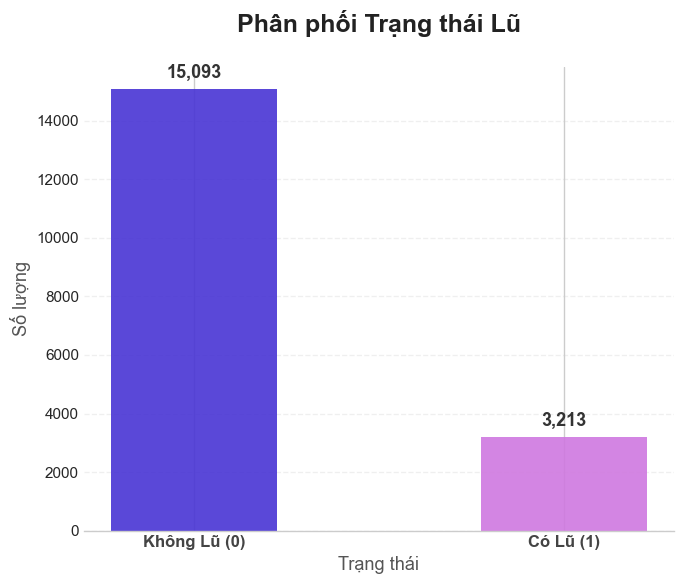

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
# Lưu ý: Đảm bảo 'query' và 'conn' đã được định nghĩa đúng
df = pd.read_sql(query, conn)

# 2. Tính toán phân phối cho cột 'flood'
# Lưu kết quả vào biến 'counts' để sử dụng cho biểu đồ
counts = df["flood"].value_counts().sort_index()

# 3. Vẽ biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(7, 6))

# Bảng màu
colors = ["#4834D4", "#CF78E0"]  
bars = ax.bar(counts.index.astype(str), counts.values, color=colors, edgecolor='none', width=0.45, alpha=0.9)

# Nhãn số phía trên thanh
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + (max(counts)*0.015),
            f'{height:,}', ha='center', va='bottom', fontsize=13, fontweight='bold', color='#333333')

# Tiêu đề và nhãn trục
plt.title("Phân phối Trạng thái Lũ", fontsize=18, fontweight='bold', color='#222222', pad=25)
plt.xlabel("Trạng thái", fontsize=13, fontweight='medium', color='#555555')
plt.ylabel("Số lượng", fontsize=13, fontweight='medium', color='#555555')

# Cấu hình nhãn trục X
plt.xticks(ticks=[0, 1], labels=["Không Lũ (0)", "Có Lũ (1)"], fontsize=12, fontweight='bold', color='#444444')

# Tối giản hóa khung
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Phân tích phân phối biến mục tiêu (Flood)

Biểu đồ thể hiện số lượng mẫu thuộc hai lớp của biến mục tiêu `flood`.

- Không lũ (0): 15.073 mẫu.
- Có lũ (1): 3.213 mẫu.

Tổng số quan sát là 18.286 mẫu.

Tỷ lệ phân bố của hai lớp:

- Không lũ: khoảng 82,4%.
- Có lũ: khoảng 17,6%.

### Nhận xét

Quan sát biểu đồ cho thấy dữ liệu bị mất cân bằng giữa hai lớp. Số lượng mẫu không xảy ra lũ lớn gấp khoảng 4,7 lần số lượng mẫu xảy ra lũ.

Sự mất cân bằng này phản ánh đúng đặc điểm của dữ liệu thực tế. Trong một khoảng thời gian dài, phần lớn các ngày không xảy ra ngập lụt, trong khi các sự kiện ngập chỉ xuất hiện ở một số thời điểm có điều kiện thời tiết cực đoan.

Tuy nhiên, sự mất cân bằng cũng tạo ra nhiều thách thức trong quá trình xây dựng mô hình.

Nếu mô hình học trực tiếp trên tập dữ liệu này mà không xử lý mất cân bằng, thuật toán sẽ có xu hướng ưu tiên dự đoán lớp "Không lũ" để đạt độ chính xác cao.

Ví dụ, nếu mô hình luôn dự đoán mọi mẫu đều là "Không lũ", độ chính xác đạt:

Accuracy = 15073 / 18286 ≈ 82,4%

Mặc dù Accuracy khá cao nhưng mô hình hoàn toàn không phát hiện được bất kỳ trường hợp xảy ra lũ nào. Đây là mô hình không có giá trị trong bài toán cảnh báo thiên tai.

Do mục tiêu của hệ thống là phát hiện sớm nguy cơ ngập lụt trước 3 ngày, việc bỏ sót các trường hợp xảy ra lũ (False Negative) gây hậu quả nghiêm trọng hơn nhiều so với việc cảnh báo nhầm (False Positive).

Vì vậy Accuracy không phải là chỉ số đánh giá phù hợp cho bài toán này.

---

## Ảnh hưởng đến việc lựa chọn chỉ số đánh giá

Đối với dữ liệu mất cân bằng, cần ưu tiên các chỉ số phản ánh khả năng nhận diện lớp xảy ra lũ như:

- Precision.
- Recall.
- F1-score.
- ROC-AUC.
- PR-AUC.

Trong đó Recall của lớp "Có lũ" là chỉ số đặc biệt quan trọng vì thể hiện tỷ lệ các trận lũ được mô hình phát hiện thành công.

---

## Ảnh hưởng đến quá trình huấn luyện

Biểu đồ cho thấy cần áp dụng các kỹ thuật xử lý dữ liệu mất cân bằng trước hoặc trong quá trình huấn luyện.

Một số hướng xử lý phù hợp gồm:

- Thiết lập `class_weight="balanced"` đối với Logistic Regression, Decision Tree hoặc Random Forest.
- Thiết lập tham số `scale_pos_weight` khi sử dụng XGBoost hoặc LightGBM.
- Oversampling lớp xảy ra lũ bằng SMOTE hoặc ADASYN.
- Undersampling lớp không xảy ra lũ nếu cần giảm chênh lệch giữa hai lớp.
- Điều chỉnh ngưỡng phân loại (Decision Threshold) để tăng Recall của lớp xảy ra lũ.

---

## Định hướng lựa chọn mô hình

Bài toán dự báo ngập lụt trước 3 ngày có các đặc điểm:

- Dữ liệu mất cân bằng.
- Quan hệ giữa các biến mang tính phi tuyến.
- Hiện tượng ngập chịu ảnh hưởng đồng thời của nhiều yếu tố khí tượng và thủy văn.
- Có các đặc trưng thời gian như lượng mưa tích lũy và xu hướng thay đổi lưu lượng nước.

Do đó các mô hình cây tăng cường như XGBoost hoặc LightGBM là lựa chọn phù hợp vì:

- Học tốt quan hệ phi tuyến.
- Xử lý tương tác giữa nhiều đặc trưng.
- Hỗ trợ xử lý dữ liệu mất cân bằng thông qua trọng số lớp.
- Hoạt động hiệu quả trên dữ liệu dạng bảng.

Random Forest cũng là một mô hình phù hợp để so sánh vì có khả năng chống overfitting và ít yêu cầu tiền xử lý dữ liệu.

---

## Kết luận

Biểu đồ cho thấy tập dữ liệu có sự mất cân bằng đáng kể giữa hai lớp, với số mẫu không xảy ra lũ chiếm hơn 80% tổng số quan sát. Đây là đặc điểm phổ biến của các bài toán dự báo thiên tai nhưng cũng làm tăng nguy cơ mô hình thiên lệch về lớp đa số.

Do mục tiêu của nghiên cứu là dự báo sớm các sự kiện ngập lụt trước 3 ngày, mô hình cần ưu tiên khả năng phát hiện đúng các trường hợp xảy ra lũ thay vì chỉ đạt Accuracy cao. Vì vậy, quá trình xây dựng mô hình cần kết hợp các kỹ thuật xử lý dữ liệu mất cân bằng và lựa chọn các chỉ số đánh giá phù hợp như Recall, F1-score và ROC-AUC để đánh giá toàn diện hiệu quả dự báo.

# CREATE FEATURES|

### Mưa tích lũy 3 ngày

In [50]:
df["rainfall_3d"] = (
    df.groupby("location_id")["rainfall"]
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=3
        ).sum()
    )
)

### Mưa tích lũy 7 ngày 

In [51]:
df["rainfall_7d"] = (
    df.groupby("location_id")["rainfall"]
    .transform(
        lambda x: x.rolling(
            window=7,
            min_periods=7
        ).sum()
    )
)

df.head()

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,rainfall_3d,rainfall_7d
0,1,Hue,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0,NaN,NaN
1,1,Hue,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0,NaN,NaN
2,1,Hue,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0,2.0,NaN
3,1,Hue,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0,15.8,NaN
4,1,Hue,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0,15.6,NaN


### Mức thay đổi lưu lượng sông:
* Giá trị dương: nước sông đang tăng
* Giá trị âm: nước sông đang giảm
* Giá trị lớn: nước đang tăng nhanh

In [52]:
df["discharge_change_1d"] = (
    df.groupby("location_id")["river_discharge"]
    .diff(1)
)

df.head()

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,rainfall_3d,rainfall_7d,discharge_change_1d
0,1,Hue,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0,NaN,NaN,NaN
1,1,Hue,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0,NaN,NaN,-0.09
2,1,Hue,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0,2.0,NaN,-0.02
3,1,Hue,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0,15.8,NaN,0.02
4,1,Hue,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0,15.6,NaN,-0.03


In [53]:
# xóa các dòng null ở đầu 
df = df.dropna().reset_index(drop=True)

### tạo 3 target ngày cần đoán

In [54]:
df["target_d1"] = (
    df.groupby("location_id")["flood"]
    .shift(-1)
)

df["target_d2"] = (
    df.groupby("location_id")["flood"]
    .shift(-2)
)

df["target_d3"] = (
    df.groupby("location_id")["flood"]
    .shift(-3)
)

df.tail()

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,rainfall_3d,rainfall_7d,discharge_change_1d,target_d1,target_d2,target_d3
18289,2,Quang Nam,2026-07-18,2.8,33.599998,50.0,1004.000000,15.1,6.85,0,4.7,21.3,-0.96,0.0,0.0,0.0
18290,2,Quang Nam,2026-07-19,0.4,33.900002,47.0,1004.200012,10.7,6.64,0,4.5,14.3,-0.21,0.0,0.0,0.0
18291,2,Quang Nam,2026-07-20,2.1,32.799999,52.0,1004.700012,19.9,6.53,0,5.3,7.9,-0.11,0.0,0.0,NaN
18292,2,Quang Nam,2026-07-21,0.1,33.400002,49.0,1005.400024,13.0,6.41,0,2.6,7.6,-0.12,0.0,NaN,NaN
18293,2,Quang Nam,2026-07-22,2.3,32.299999,55.0,1005.599976,20.6,6.18,0,4.5,9.6,-0.23,NaN,NaN,NaN


In [55]:
df = df.dropna(
    subset=["target_d1", "target_d2", "target_d3"]
).reset_index(drop=True)

df.tail()

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,rainfall_3d,rainfall_7d,discharge_change_1d,target_d1,target_d2,target_d3
18283,2,Quang Nam,2026-07-15,0.3,32.200001,59.0,1004.700012,20.6,7.57,0,9.2,32.200000,0.160000,0.0,0.0,0.0
18284,2,Quang Nam,2026-07-16,0.6,33.500000,50.0,1005.200012,19.9,8.27,0,1.3,29.500001,0.700000,0.0,0.0,0.0
18285,2,Quang Nam,2026-07-17,1.3,33.500000,50.0,1004.700012,16.6,7.81,0,2.2,19.700000,-0.460001,0.0,0.0,0.0
18286,2,Quang Nam,2026-07-18,2.8,33.599998,50.0,1004.000000,15.1,6.85,0,4.7,21.300000,-0.960000,0.0,0.0,0.0
18287,2,Quang Nam,2026-07-19,0.4,33.900002,47.0,1004.200012,10.7,6.64,0,4.5,14.300000,-0.210000,0.0,0.0,0.0


In [56]:
target_cols = [
    'target_d1',
    'target_d2',
    'target_d3'
]

df[target_cols] = df[target_cols].astype('int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18288 entries, 0 to 18287
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   location_id          18288 non-null  int64  
 1   location             18288 non-null  object 
 2   date                 18288 non-null  object 
 3   rainfall             18288 non-null  float64
 4   temperature          18288 non-null  float64
 5   humidity             18288 non-null  float64
 6   pressure             18288 non-null  float64
 7   wind_speed           18288 non-null  float64
 8   river_discharge      18288 non-null  float64
 9   flood                18288 non-null  int64  
 10  rainfall_3d          18288 non-null  float64
 11  rainfall_7d          18288 non-null  float64
 12  discharge_change_1d  18288 non-null  float64
 13  target_d1            18288 non-null  int64  
 14  target_d2            18288 non-null  int64  
 15  target_d3            18288 non-null 

In [57]:
df.head()

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,rainfall_3d,rainfall_7d,discharge_change_1d,target_d1,target_d2,target_d3
0,1,Hue,2001-07-07,0.5,30.200001,68.0,998.400024,23.1,0.36,0,0.5,16.3,-0.01,0,0,0
1,1,Hue,2001-07-08,38.0,28.400000,82.0,1003.099976,6.2,0.70,0,38.5,54.3,0.34,0,0,0
2,1,Hue,2001-07-09,6.7,28.000000,80.0,1006.400024,8.1,1.28,0,45.2,60.8,0.58,0,0,0
3,1,Hue,2001-07-10,0.2,28.200001,79.0,1006.200012,9.2,0.92,0,44.9,59.2,-0.36,0,0,0
4,1,Hue,2001-07-11,0.8,28.600000,80.0,1004.700012,9.1,0.58,0,7.7,46.2,-0.34,0,0,0


In [58]:
df.columns

Index(['location_id', 'location', 'date', 'rainfall', 'temperature',
       'humidity', 'pressure', 'wind_speed', 'river_discharge', 'flood',
       'rainfall_3d', 'rainfall_7d', 'discharge_change_1d', 'target_d1',
       'target_d2', 'target_d3'],
      dtype='object')

In [59]:
df.to_csv("../data/train/train_data.csv",index = False)
print("done")

done


### 3.Xu hướng lượng mưa